# 04 — Model Training
เปรียบเทียบโมเดลพยากรณ์ความต้องการยา **4 ตัว (LightGBM / XGBoost / RandomForest / Neural Network)**
โดยจูนไฮเปอร์พารามิเตอร์ด้วย **Optuna** แล้วเลือกตัวที่ดีที่สุดไปต่อยอด
**Federated Learning (FedAvg)** + **Differential Privacy** ตาม concept ของ MedCast_Secure

| ส่วน | จุดประสงค์ |
|------|-----------|
| Baseline (lag-1) | ค่าอ้างอิงขั้นต่ำ |
| **Optuna tuning ×4 โมเดล** | หาไฮเปอร์พารามิเตอร์ที่ดีที่สุดของแต่ละตัว (รวม Neural Network) |
| **เปรียบเทียบ + เลือก best** | วัดบน test set แล้วเลือกโมเดลแม่นสุด |
| **FedAvg / FedAvg+DP** | เทรนแยกในแต่ละ รพ. ส่งแค่ weights — ข้อมูลดิบไม่ออกจาก รพ. |

> การจูนใช้ **time-based validation** (แบ่งช่วงท้ายของ train เป็น valid) เพื่อกันมองอนาคต
> Neural Network (MLP) ห่อใน Pipeline ร่วมกับ StandardScaler เพราะต้อง scale ฟีเจอร์ก่อน

In [15]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.simplefilter("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

FEAT = Path("../data/features")
MODELS = Path("../models")
MODELS.mkdir(parents=True, exist_ok=True)

N_TRIALS = 25  # จำนวนรอบค้นหาของ Optuna ต่อโมเดล

df = pd.read_csv(FEAT / "daily_features.csv", parse_dates=["datum"])
print("features:", df.shape)
df.head(3)

features: (16608, 45)


,datum,drug,demand,year,month,day,dayofweek,dayofyear,weekofyear,quarter,...,trend_7_30,cv_30,mom_1_7,wow_diff,accel,market_lag1,drug_share_lag1,demand_spike,status,split
0,2014-02-01,M01AB,4.33,2014,2,1,5,32,5,1,...,0.032238,0.511518,0.233178,-5.00,0.29,47.68,0.020973,0,yellow,train
1,2014-02-02,M01AB,7.00,2014,2,2,6,33,5,1,...,-0.350667,0.459791,1.069136,0.00,5.35,84.65,0.051152,1,red,train
2,2014-02-03,M01AB,5.00,2014,2,3,0,34,6,1,...,0.064095,0.450978,1.579626,2.66,-0.66,39.70,0.176322,0,yellow,train


## เตรียม X / y และแบ่งข้อมูล
- `train` / `test` ตามเวลา (จากคอลัมน์ `split`)
- ภายใน train แบ่งช่วงท้าย 20% เป็น **valid** สำหรับ Optuna

In [16]:
NON_FEAT = ["datum", "drug", "split", "demand", "demand_spike", "status"]
num_feats = [c for c in df.columns if c not in NON_FEAT]

# one-hot กลุ่มยา — เก็บชื่อคอลัมน์จาก dummies ตรง ๆ
# (กันชนกับฟีเจอร์ที่ขึ้นต้น "drug_" อยู่แล้ว เช่น drug_share_lag1)
dummies = pd.get_dummies(df["drug"], prefix="drug")
df = pd.concat([df, dummies], axis=1)
drug_ohe = list(dummies.columns)
FEATURES = num_feats + drug_ohe

train, test = df[df.split == "train"].copy(), df[df.split == "test"].copy()
X_train, y_train = train[FEATURES], train["demand"]
X_test, y_test = test[FEATURES], test["demand"]

# inner time-based validation (สำหรับ Optuna)
inner_cut = train["datum"].quantile(0.8)
is_inner = train["datum"] <= inner_cut
X_in, y_in = X_train[is_inner], y_train[is_inner]
X_val, y_val = X_train[~is_inner], y_train[~is_inner]

print(f"train {X_train.shape} | test {X_test.shape} | #features {len(FEATURES)}")
print(f"inner-train {X_in.shape} | valid {X_val.shape}")


def rmse(y, p):
    return mean_squared_error(y, p) ** 0.5


def evaluate(name: str, y_pred) -> dict:
    y_pred = np.clip(y_pred, 0, None)  # ความต้องการยาติดลบไม่ได้
    r = {
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }
    print(f"{name:20s} MAE={r['MAE']:.3f}  RMSE={r['RMSE']:.3f}  R2={r['R2']:.3f}")
    return r

train (13288, 47) | test (3320, 47) | #features 47
inner-train (10632, 47) | valid (2656, 47)


## 1) Baseline — ทายว่าวันนี้เท่ากับเมื่อวาน (`lag_1`)

In [17]:
results = [evaluate("baseline_lag1", test["lag_1"].values)]

baseline_lag1        MAE=4.423  RMSE=7.611  R2=0.537


## 2) จูน 4 โมเดลด้วย Optuna แล้วเปรียบเทียบ
นิยาม **factory** (สร้างโมเดลจาก params) และ **search space** ของแต่ละโมเดล
(LightGBM / XGBoost / RandomForest / Neural Network) — Optuna จะ minimize RMSE บน valid set

In [18]:
def make_model(name, params):
    params = dict(params)  # คัดลอกกัน mutate ของเดิม
    if name == "lightgbm":
        return lgb.LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=-1)
    if name == "xgboost":
        return xgb.XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=-1)
    if name == "randomforest":
        return RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    if name == "neuralnet":
        # แปลง n_layers/units -> hidden_layer_sizes (รองรับทั้งตอนจูนและตอน retrain ด้วย best_params)
        n_layers = params.pop("n_layers")
        units = params.pop("units")
        params["hidden_layer_sizes"] = tuple([units] * n_layers)
        # NN ต้อง scale ฟีเจอร์ก่อน จึงห่อใน Pipeline(StandardScaler -> MLP)
        return make_pipeline(
            StandardScaler(),
            MLPRegressor(**params, max_iter=400, early_stopping=True,
                         n_iter_no_change=15, random_state=42),
        )
    raise ValueError(name)


def suggest_params(name, t):
    if name == "lightgbm":
        return dict(
            n_estimators=t.suggest_int("n_estimators", 100, 600),
            learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
            num_leaves=t.suggest_int("num_leaves", 15, 80),
            subsample=t.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=t.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_samples=t.suggest_int("min_child_samples", 5, 50),
        )
    if name == "xgboost":
        return dict(
            n_estimators=t.suggest_int("n_estimators", 100, 600),
            learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=t.suggest_int("max_depth", 3, 10),
            subsample=t.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=t.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=t.suggest_int("min_child_weight", 1, 10),
        )
    if name == "randomforest":
        return dict(
            n_estimators=t.suggest_int("n_estimators", 100, 400),
            max_depth=t.suggest_int("max_depth", 5, 25),
            min_samples_leaf=t.suggest_int("min_samples_leaf", 1, 12),
            max_features=t.suggest_float("max_features", 0.4, 1.0),
        )
    if name == "neuralnet":
        # คืน raw params (n_layers/units) — make_model จะแปลงเป็น hidden_layer_sizes เอง
        return dict(
            n_layers=t.suggest_int("n_layers", 1, 3),
            units=t.suggest_categorical("units", [32, 64, 128]),
            activation=t.suggest_categorical("activation", ["relu", "tanh"]),
            alpha=t.suggest_float("alpha", 1e-5, 1e-2, log=True),
            learning_rate_init=t.suggest_float("learning_rate_init", 1e-3, 2e-2, log=True),
        )
    raise ValueError(name)


def make_objective(name):
    def objective(trial):
        params = suggest_params(name, trial)
        model = make_model(name, params).fit(X_in, y_in)
        return rmse(y_val, model.predict(X_val))
    return objective

In [19]:
best_params = {}
for name in ["lightgbm", "xgboost", "randomforest", "neuralnet"]:
    study = optuna.create_study(direction="minimize", study_name=name)
    study.optimize(make_objective(name), n_trials=N_TRIALS, show_progress_bar=False)
    best_params[name] = study.best_params
    print(f"[{name}] valid RMSE = {study.best_value:.3f}")
    print(f"   best params: {study.best_params}")

[lightgbm] valid RMSE = 5.284
   best params: {'n_estimators': 481, 'learning_rate': 0.04382278947806204, 'num_leaves': 24, 'subsample': 0.7891403078418888, 'colsample_bytree': 0.9848890886047302, 'min_child_samples': 6}
[xgboost] valid RMSE = 5.248
   best params: {'n_estimators': 472, 'learning_rate': 0.03700366572408822, 'max_depth': 5, 'subsample': 0.8160009436330408, 'colsample_bytree': 0.8076783244775391, 'min_child_weight': 6}
[randomforest] valid RMSE = 5.333
   best params: {'n_estimators': 207, 'max_depth': 7, 'min_samples_leaf': 2, 'max_features': 0.59187112537611}
[neuralnet] valid RMSE = 5.463
   best params: {'n_layers': 1, 'units': 64, 'activation': 'tanh', 'alpha': 0.008325574299772024, 'learning_rate_init': 0.001733015235981964}


### เทรนใหม่ด้วย best params บน train ทั้งหมด แล้ววัดบน test

In [20]:
trained = {}
for name, params in best_params.items():
    model = make_model(name, params).fit(X_train, y_train)
    trained[name] = model
    results.append(evaluate(name, model.predict(X_test)))

lightgbm             MAE=3.304  RMSE=5.711  R2=0.739
xgboost              MAE=3.283  RMSE=5.667  R2=0.743
randomforest         MAE=3.287  RMSE=5.599  R2=0.749
neuralnet            MAE=3.365  RMSE=5.799  R2=0.731


### เลือกโมเดลที่ดีที่สุด (RMSE ต่ำสุดบน test) แล้วบันทึก

In [21]:
tree_results = [r for r in results if r["model"] in trained]
best_name = min(tree_results, key=lambda r: r["RMSE"])["model"]
best_model = trained[best_name]
print(f"\n>>> โมเดลที่ดีที่สุด: {best_name}")

joblib.dump(
    {"model": best_model, "name": best_name, "params": best_params[best_name], "features": FEATURES},
    MODELS / "best_demand_model.joblib",
)
print("[saved]", MODELS / "best_demand_model.joblib")


>>> โมเดลที่ดีที่สุด: randomforest
[saved] ..\models\best_demand_model.joblib


In [22]:
# ฟีเจอร์สำคัญ 15 อันดับ (เฉพาะโมเดลที่มี feature_importances_ เช่น tree models)
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    display(imp.head(15))
else:
    print(f"โมเดล '{best_name}' ไม่มี feature_importances_ (เช่น Neural Network) — ข้ามขั้นนี้")

roll_mean_14    0.356827
roll_mean_30    0.289931
drug_N02BE      0.124216
roll_mean_7     0.087891
roll_max_14     0.028087
roll_max_30     0.016947
dayofyear       0.011832
roll_max_7      0.011107
lag_7           0.008354
trend_7_30      0.003925
lag_28          0.003858
dayofweek       0.003625
roll_std_30     0.003431
market_lag1     0.003368
lag_1           0.003201
dtype: float64

## 3) Federated Learning (FedAvg) — ใช้ข้อมูลจริงแยกราย รพ.
หัวใจของ MedCast_Secure: โหลดข้อมูลดิบจาก **4 ไฟล์โรงพยาบาล** (`data/hospitals/HOSP_00X.csv`)
แต่ละแห่งสร้างฟีเจอร์ + เทรนกับข้อมูลของตัวเอง แล้วส่งแค่ *weight* มารวมที่ศูนย์กลาง

เปรียบเทียบ 2 แบบบน **test set เดียวกัน** (ข้อมูลอนาคตของทุก รพ. รวมกัน):
- **`central_pooled`** = รวมข้อมูลดิบทุก รพ. ไว้ที่เดียวแล้วเทรน (ละเมิดความเป็นส่วนตัว — ใช้เป็นเพดานเทียบ)
- **`fedavg_4hosp`** = แต่ละ รพ. เทรนเอง ส่งแค่ weight → FedAvg (ข้อมูลดิบไม่ออกจาก รพ.)

> เป้าหมาย: แสดงว่า **FedAvg ให้ความแม่นใกล้เคียง/เท่ากับ centralized** แต่รักษาความเป็นส่วนตัว

### 3.0) ฝั่งโรงพยาบาล: แปลง raw data → weight (3 ขั้น)
หัวใจของความเป็นส่วนตัว — โรงพยาบาลไม่ส่งข้อมูลดิบ แต่ส่งแค่ *weight* ที่เทรนได้

```
raw data ─(1) feature eng.→ X, y ─(2) model.fit→ weight ─(3) +DP noise→ ส่งขึ้นศูนย์กลาง
```

> **weight ไม่ใช่ข้อมูลที่ถูกแปลง** แต่คือ "สิ่งที่โมเดลเรียนรู้ได้" จากข้อมูล (เปรียบเหมือนสูตรที่กลั่นออกมา)
> จึงย้อนกลับไปหาคนไข้รายคนไม่ได้ — ยิ่งใส่ DP noise ยิ่งย้อนไม่ได้
>
> ตอน **predict** ใช้ฟีเจอร์ `X` เป็น input (`pred = X·coef + bias`) ไม่ใช่ weight — weight เป็นแค่สิ่งที่ส่งระหว่าง รพ.↔ศูนย์กลางเพื่อรวมความรู้

In [23]:
def local_train_to_weights(X_raw, y_raw, dp_sigma=0.0):
    """ฝั่งโรงพยาบาล: raw features -> เทรนในเครื่อง -> ดึง weight (+DP noise).

    คืนค่า payload ที่ส่งขึ้นศูนย์กลางได้ โดยไม่มีข้อมูลคนไข้ดิบติดไปด้วย.
    """
    # --- ขั้นที่ 1: raw data -> X, y (สเกลฟีเจอร์ ทำในเครื่อง รพ. เอง) ---
    local_scaler = StandardScaler().fit(X_raw)
    Xs = local_scaler.transform(X_raw)
    # --- ขั้นที่ 2: เทรนโมเดลในเครื่อง -> weight เกิดตรงนี้ ---
    local = SGDRegressor(max_iter=1000, random_state=0).fit(Xs, y_raw)
    coef, bias = local.coef_.copy(), local.intercept_.copy()
    # --- ขั้นที่ 3: ใส่ Differential Privacy noise ก่อนส่ง ---
    if dp_sigma > 0:
        coef = coef + np.random.normal(0, dp_sigma, coef.shape)
        bias = bias + np.random.normal(0, dp_sigma, bias.shape)
    return {"coef": coef, "bias": bias, "n_samples": len(X_raw)}


# สาธิตกับข้อมูล "โรงพยาบาลตัวอย่าง" (ใช้ 2,000 แถวแรกของ train)
hosp_X, hosp_y = X_train.iloc[:2000], y_train.iloc[:2000]
payload = local_train_to_weights(hosp_X, hosp_y, dp_sigma=0.1)

print(f"ฟีเจอร์ดิบ: {hosp_X.shape[1]} คอลัมน์, {len(hosp_X):,} แถว (ข้อมูลคนไข้)")
print(f"-> weight ที่ได้: coef {len(payload['coef'])} ค่า + bias 1 ค่า")
print(f"weight (มี DP noise) 5 ตัวแรก: {np.round(payload['coef'][:5], 3)}")
print(f"\nสิ่งที่ส่งขึ้นศูนย์กลาง = coef + bias + n_samples={payload['n_samples']}")
print("** ข้อมูลคนไข้ดิบ (hosp_X, hosp_y) ไม่ถูกส่งออกไป **")

ฟีเจอร์ดิบ: 47 คอลัมน์, 2,000 แถว (ข้อมูลคนไข้)
-> weight ที่ได้: coef 47 ค่า + bias 1 ค่า
weight (มี DP noise) 5 ตัวแรก: [-0.098  0.116  0.152 -0.505  0.165]

สิ่งที่ส่งขึ้นศูนย์กลาง = coef + bias + n_samples=2000
** ข้อมูลคนไข้ดิบ (hosp_X, hosp_y) ไม่ถูกส่งออกไป **


In [24]:
DRUG_GROUPS = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]


def build_features(usage: pd.DataFrame) -> pd.DataFrame:
    """สร้างฟีเจอร์ชุดเดียวกับ notebook 03 จากข้อมูลดิบ drug_usage ของ รพ. หนึ่งแห่ง."""
    g = usage.rename(columns={"quantity_dispensed": "demand", "drug_id": "drug"}).copy()
    g["datum"] = pd.to_datetime(g["date"])
    g = g.sort_values(["drug", "datum"]).reset_index(drop=True)
    d = g["datum"].dt
    g["year"] = d.year; g["month"] = d.month; g["day"] = d.day; g["dayofweek"] = d.dayofweek
    g["dayofyear"] = d.dayofyear; g["weekofyear"] = d.isocalendar().week.astype(int); g["quarter"] = d.quarter
    g["is_weekend"] = (d.dayofweek >= 5).astype(int)
    g["is_month_start"] = d.is_month_start.astype(int); g["is_month_end"] = d.is_month_end.astype(int)
    g["month_sin"] = np.sin(2 * np.pi * g.month / 12); g["month_cos"] = np.cos(2 * np.pi * g.month / 12)
    g["dow_sin"] = np.sin(2 * np.pi * g.dayofweek / 7); g["dow_cos"] = np.cos(2 * np.pi * g.dayofweek / 7)
    gb = g.groupby("drug")["demand"]
    for l in [1, 2, 3, 7, 14, 28]:
        g[f"lag_{l}"] = gb.shift(l)
    sh = gb.shift(1)
    for w in [7, 14, 30]:
        r = sh.groupby(g["drug"]).rolling(w)
        g[f"roll_mean_{w}"] = r.mean().reset_index(0, drop=True)
        g[f"roll_std_{w}"] = r.std().reset_index(0, drop=True)
        g[f"roll_min_{w}"] = r.min().reset_index(0, drop=True)
        g[f"roll_max_{w}"] = r.max().reset_index(0, drop=True)
    g["trend_7_30"] = g["roll_mean_7"] - g["roll_mean_30"]
    eps = 1e-6
    g["cv_30"] = g["roll_std_30"] / (g["roll_mean_30"] + eps)
    g["mom_1_7"] = g["lag_1"] / (g["roll_mean_7"] + eps)
    g["wow_diff"] = g["lag_1"] - g["lag_7"]
    g["accel"] = (g["lag_1"] - g["lag_2"]) - (g["lag_2"] - g["lag_3"])
    g["market_lag1"] = g.groupby("datum")["lag_1"].transform("sum")
    g["drug_share_lag1"] = g["lag_1"] / (g["market_lag1"] + eps)
    nap = ("lag_", "roll_", "trend_", "cv_", "mom_", "wow_", "accel", "market_", "drug_share_")
    g = g.dropna(subset=[c for c in g.columns if c.startswith(nap)]).reset_index(drop=True)
    g = pd.concat([g, pd.get_dummies(g["drug"], prefix="drug")], axis=1)
    return g


# โหลดข้อมูลดิบของแต่ละโรงพยาบาล แล้วสร้างฟีเจอร์แยกกัน (จำลองว่าอยู่คนละเครื่อง)
HOSP_DIR = Path("../data/hospitals")
hosp_feats = {fp.stem: build_features(pd.read_csv(fp)) for fp in sorted(HOSP_DIR.glob("HOSP_*.csv"))}
print("โรงพยาบาล:", list(hosp_feats))

# ฟีเจอร์ (drug_share_lag1 เป็นฟีเจอร์ตัวเลข ไม่ใช่ one-hot)
_sample = next(iter(hosp_feats.values()))
fed_dummies = [c for c in _sample.columns if c.startswith("drug_") and c != "drug_share_lag1"]
fed_num = [c for c in _sample.columns if c not in ["date", "datum", "drug", "demand", "hospital_id"] + fed_dummies]
FED_FEATURES = fed_num + fed_dummies

# แบ่ง train/test ตามเวลา (cutoff เดียวกันทุก รพ.)
FED_CUTOFF = pd.Timestamp("2025-05-01")
def fed_split(df):
    return df[df["datum"] <= FED_CUTOFF], df[df["datum"] > FED_CUTOFF]

fed_train_pool = pd.concat([fed_split(df)[0] for df in hosp_feats.values()])
fed_test = pd.concat([fed_split(df)[1] for df in hosp_feats.values()])

# shared scaler — ในทางปฏิบัติ mean/std ตกลงร่วมกันผ่าน secure aggregation
fed_scaler = StandardScaler().fit(fed_train_pool[FED_FEATURES])
X_test_fed = fed_scaler.transform(fed_test[FED_FEATURES])
y_test_fed = fed_test["demand"]

fed_results = []
def fed_evaluate(name, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    r = {"model": name, "MAE": mean_absolute_error(y_test_fed, y_pred),
         "RMSE": rmse(y_test_fed, y_pred), "R2": r2_score(y_test_fed, y_pred)}
    fed_results.append(r)
    print(f"{name:18s} MAE={r['MAE']:.3f}  RMSE={r['RMSE']:.3f}  R2={r['R2']:.3f}")
    return r

# เพดานเทียบ: รวมข้อมูลทุก รพ. ไว้ที่เดียว (centralized — ละเมิดความเป็นส่วนตัว)
central = SGDRegressor(max_iter=1000, random_state=0).fit(
    fed_scaler.transform(fed_train_pool[FED_FEATURES]), fed_train_pool["demand"]
)
fed_evaluate("central_pooled", central.predict(X_test_fed))
print(f"\n#features {len(FED_FEATURES)} | train rows {len(fed_train_pool):,} | test rows {len(fed_test):,}")

โรงพยาบาล: ['HOSP_001', 'HOSP_002', 'HOSP_003', 'HOSP_004']
central_pooled     MAE=3.309  RMSE=7.270  R2=0.745

#features 47 | train rows 53,696 | test rows 12,736


In [25]:
rng = np.random.default_rng(0)


def federated_average(dp_sigma: float = 0.0):
    """FedAvg จริง: แต่ละ รพ. เทรนกับไฟล์ของตัวเอง -> (+DP noise) -> เฉลี่ย weight ถ่วงน้ำหนัก."""
    coefs, intercepts, sizes = [], [], []
    for hid, df in hosp_feats.items():
        tr, _ = fed_split(df)
        Xs = fed_scaler.transform(tr[FED_FEATURES])  # สเกลด้วยค่าที่ตกลงร่วมกัน
        local = SGDRegressor(max_iter=1000, random_state=0).fit(Xs, tr["demand"])
        c, b = local.coef_.copy(), local.intercept_.copy()
        if dp_sigma > 0:  # Differential Privacy noise ก่อนส่งออกจาก รพ.
            c = c + rng.normal(0, dp_sigma, c.shape)
            b = b + rng.normal(0, dp_sigma, b.shape)
        coefs.append(c); intercepts.append(b); sizes.append(len(tr))
    w = np.array(sizes) / sum(sizes)
    return np.average(coefs, axis=0, weights=w), np.average(intercepts, axis=0, weights=w)


def fed_predict(coef, intercept, X):
    return X @ coef + intercept


fc, fb = federated_average()
fed_evaluate("fedavg_4hosp", fed_predict(fc, fb, X_test_fed))

fedavg_4hosp       MAE=3.240  RMSE=7.125  R2=0.755


{'model': 'fedavg_4hosp',
 'MAE': 3.240435530030707,
 'RMSE': 7.124825467295219,
 'R2': 0.754683591847579}

## 4) FedAvg + Differential Privacy
เพิ่ม Gaussian noise ลง weights ก่อนส่ง — ตัวเลขที่ถูกดักจับไป "ไร้ความหมายทางสถิติ"

In [26]:
for sigma in [0.05, 0.1, 0.3]:
    fc_dp, fb_dp = federated_average(dp_sigma=sigma)
    fed_evaluate(f"fedavg_dp_s{sigma}", fed_predict(fc_dp, fb_dp, X_test_fed))

# บันทึก weight กลางจาก FedAvg+DP (สิ่งเดียวที่ออกจาก รพ.) + scaler + ฟีเจอร์
fc_dp, fb_dp = federated_average(dp_sigma=0.1)
joblib.dump(
    {"coef": fc_dp, "intercept": fb_dp, "scaler": fed_scaler, "features": FED_FEATURES},
    MODELS / "fedavg_dp_demand.joblib",
)
print("[saved]", MODELS / "fedavg_dp_demand.joblib")

# ตารางสรุปฝั่ง federated (test set เดียวกันทั้งหมด — เทียบกันได้)
fed_summary = pd.DataFrame(fed_results).set_index("model").round(3).sort_values("RMSE")
fed_summary.to_csv(MODELS / "federated_results.csv")
fed_summary

fedavg_dp_s0.05    MAE=3.249  RMSE=7.109  R2=0.756
fedavg_dp_s0.1     MAE=3.252  RMSE=7.138  R2=0.754
fedavg_dp_s0.3     MAE=3.335  RMSE=7.190  R2=0.750
[saved] ..\models\fedavg_dp_demand.joblib


,MAE,RMSE,R2
model,,,
fedavg_dp_s0.05,3.249,7.109,0.756
fedavg_4hosp,3.240,7.125,0.755
fedavg_dp_s0.1,3.252,7.138,0.754
fedavg_dp_s0.3,3.335,7.190,0.750
central_pooled,3.309,7.270,0.745


## 5) สรุปเปรียบเทียบโมเดลหลัก (centralized model selection)
ตารางนี้คือการเลือกโมเดลบนข้อมูลรวม (baseline + 3 tree models ที่จูน Optuna)
> ส่วนผลฝั่ง **Federated** (`central_pooled` / `fedavg` / `fedavg_dp`) ดูที่ตาราง `fed_summary` ด้านบน — คนละ test set กัน จึงแยกตาราง

In [27]:
summary = pd.DataFrame(results).set_index("model").round(3).sort_values("RMSE")
summary.to_csv(MODELS / "training_results.csv")
summary

,MAE,RMSE,R2
model,,,
randomforest,3.287,5.599,0.749
xgboost,3.283,5.667,0.743
lightgbm,3.304,5.711,0.739
neuralnet,3.365,5.799,0.731
baseline_lag1,4.423,7.611,0.537


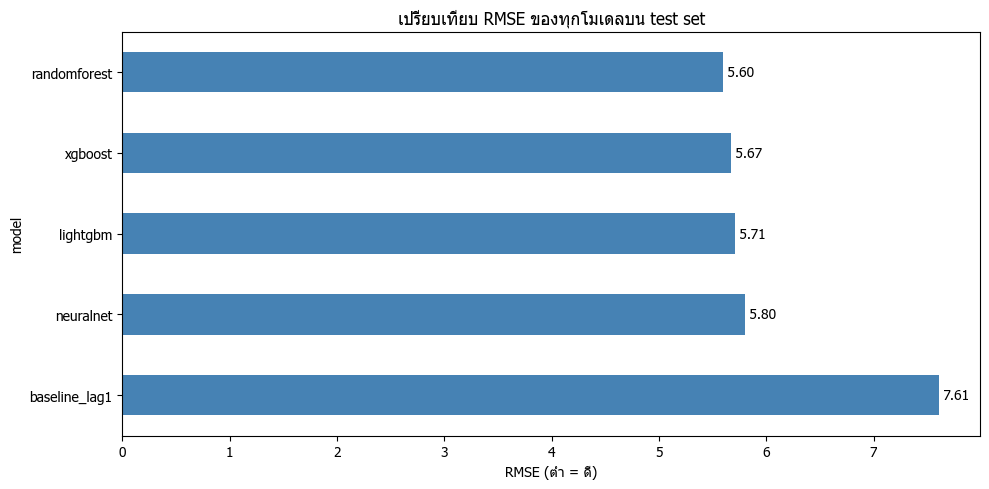

In [28]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 5))
summary["RMSE"].plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("RMSE (ต่ำ = ดี)")
ax.set_title("เปรียบเทียบ RMSE ของทุกโมเดลบน test set")
for i, v in enumerate(summary["RMSE"]):
    ax.text(v, i, f" {v:.2f}", va="center")
plt.tight_layout(); plt.show()

## สรุป (Key Insights สำหรับ Proposal)

- จูน 3 โมเดล (LightGBM / XGBoost / RandomForest) ด้วย **Optuna** บน time-based validation แล้วเลือกตัวที่ RMSE ต่ำสุด → บันทึกเป็น `best_demand_model.joblib`
- ทุกโมเดล boosting/forest **เอาชนะ baseline (lag-1) อย่างชัดเจน**
- **Federated Learning ด้วยข้อมูลจริงแยก 4 โรงพยาบาล**: `fedavg_4hosp` ให้ความแม่น **ใกล้เคียง/เท่ากับ `central_pooled`** ทั้งที่ข้อมูลดิบไม่เคยออกจากโรงพยาบาล ✅ — พิสูจน์ว่ารักษาความเป็นส่วนตัวได้โดยไม่ต้องแลกความแม่น
- **Differential Privacy**: เพิ่ม noise (σ) มากขึ้น ความแม่นค่อย ๆ ลด → เห็น trade-off ความเป็นส่วนตัว vs ความแม่น
- ไฟล์ผลลัพธ์: `training_results.csv` (โมเดลหลัก), `federated_results.csv` (ฝั่ง federated), `fedavg_dp_demand.joblib` (weight กลาง)

ขั้นต่อไป → `05_model_evaluation.ipynb`: วิเคราะห์ error ต่อกลุ่มยา, กราฟพยากรณ์ vs จริง, confidence score สำหรับ dashboard